# Notebook 2: Classical Baselines (Phase 2, Cells 6-15)



Purely classical benchmark notebook (no quantum libraries).



Scope:

- MiniBatch K-Means + Lloyd's K-Means clustering

- Hyperparameter tuning with Elbow, Silhouette, and MAE focus

- Item-based CF baseline using Sarwar adjusted cosine + weighted-sum prediction

- Metrics: RMSE, MAE, HR@10, NDCG@10, Precision@10



Primary outputs:

- `classical_clusters.npy`

- `baseline_metrics.csv`

In [13]:
from pathlib import Path

import warnings



import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

from scipy.sparse import csr_matrix, load_npz

from sklearn.cluster import KMeans, MiniBatchKMeans

from sklearn.metrics import mean_absolute_error, mean_squared_error, silhouette_score



warnings.filterwarnings("ignore", category=RuntimeWarning)



PHASE1_DIR = Path("data/processed_32m_phase1")

OUTPUT_DIR = Path("data/processed_32m_phase2")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)



RATINGS_SPARSE_PATH = PHASE1_DIR / "ratings_sparse.npz"

LATENT_PATH = PHASE1_DIR / "latent_embeddings.npy"



SEED = 42

K_CANDIDATES = [16, 24, 32, 40, 48, 64]

BATCH_SIZE = 2048

MAX_ITER = 200

EVAL_USERS = 1000

TOPK = 10

ITEM_CF_TOP_ITEMS = 1500

ITEM_CF_TOP_NEIGHBORS = 40



ratings_csr = load_npz(RATINGS_SPARSE_PATH).tocsr().astype(np.float32)

latent_embeddings = np.load(LATENT_PATH).astype(np.float32)



if ratings_csr.shape[0] != latent_embeddings.shape[0]:

    raise ValueError("User dimension mismatch between sparse ratings and latent embeddings.")



print(f"ratings_csr shape: {ratings_csr.shape}")

print(f"latent_embeddings shape: {latent_embeddings.shape}")

ratings_csr shape: (200948, 84432)
latent_embeddings shape: (200948, 32)


In [14]:
# Cell 7: Tuning with Elbow + Silhouette + MAE focus (MiniBatch and Lloyd)

obs_users, obs_items = ratings_csr.nonzero()

obs_true = ratings_csr.data.astype(np.float32)



tuning_rows = []

for k in K_CANDIDATES:

    for method in ["minibatch", "lloyd"]:

        if method == "minibatch":

            model = MiniBatchKMeans(

                n_clusters=k,

                batch_size=BATCH_SIZE,

                max_iter=MAX_ITER,

                random_state=SEED,

                n_init=10,

            )

        else:

            model = KMeans(

                n_clusters=k,

                init="k-means++",

                max_iter=MAX_ITER,

                random_state=SEED,

                n_init=10,

                algorithm="lloyd",

            )



        labels = model.fit_predict(latent_embeddings)

        centers = model.cluster_centers_.astype(np.float32)



        if len(np.unique(labels)) > 1:

            sample_size = min(10000, latent_embeddings.shape[0])

            sil = float(silhouette_score(latent_embeddings, labels, sample_size=sample_size, random_state=SEED))

        else:

            sil = np.nan



        cluster_means = np.zeros((k, ratings_csr.shape[1]), dtype=np.float32)

        for c in range(k):

            members = np.where(labels == c)[0]

            if len(members) > 0:

                cluster_means[c] = ratings_csr[members].mean(axis=0).A1.astype(np.float32)



        obs_pred = cluster_means[labels[obs_users], obs_items]

        mae = float(mean_absolute_error(obs_true, obs_pred))



        tuning_rows.append(

            {

                "method": method,

                "k": int(k),

                "inertia": float(model.inertia_),

                "silhouette": sil,

                "mae": mae,

            }

        )



tuning_df = pd.DataFrame(tuning_rows).sort_values(["method", "k"]).reset_index(drop=True)



# MAE-focused selection with silhouette as tie-breaker

best_row = tuning_df.sort_values(["mae", "silhouette"], ascending=[True, False]).iloc[0]

best_method = str(best_row["method"])

best_k = int(best_row["k"])



print(tuning_df)

print(f"Selected method: {best_method}, k: {best_k}")

       method   k     inertia  silhouette       mae
0       lloyd  16  59206136.0    0.122974  2.638182
1       lloyd  24  54158360.0    0.126522  2.595810
2       lloyd  32  50988676.0    0.120046  2.569762
3       lloyd  40  48786328.0    0.105956  2.551325
4       lloyd  48  47118664.0    0.100701  2.537220
5       lloyd  64  44620756.0    0.095298  2.514825
6   minibatch  16  60213620.0    0.122855  2.645708
7   minibatch  24  55720808.0    0.103695  2.609342
8   minibatch  32  52145616.0    0.101817  2.579193
9   minibatch  40  49758800.0    0.090975  2.558580
10  minibatch  48  48141120.0    0.071086  2.544595
11  minibatch  64  46180988.0    0.061759  2.526162
Selected method: lloyd, k: 64


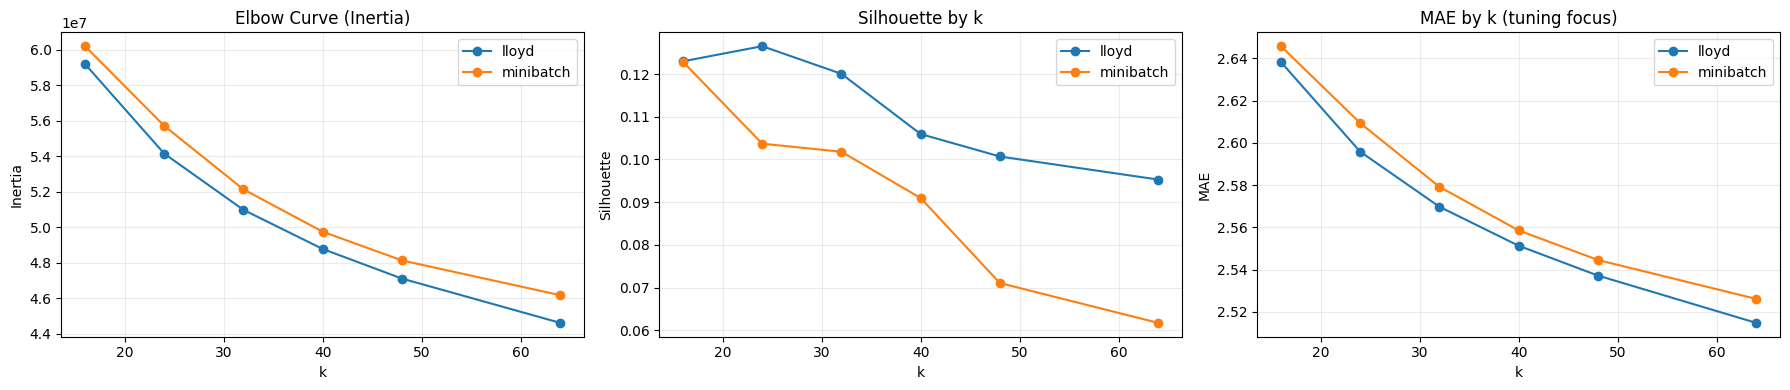

In [15]:
# Visualization 1: Elbow / Silhouette / MAE across k and method

fig, axes = plt.subplots(1, 3, figsize=(18, 4))



for method_name, group in tuning_df.groupby("method"):

    g = group.sort_values("k")

    axes[0].plot(g["k"], g["inertia"], marker="o", label=method_name)

    axes[1].plot(g["k"], g["silhouette"], marker="o", label=method_name)

    axes[2].plot(g["k"], g["mae"], marker="o", label=method_name)



axes[0].set_title("Elbow Curve (Inertia)")

axes[0].set_xlabel("k")

axes[0].set_ylabel("Inertia")



axes[1].set_title("Silhouette by k")

axes[1].set_xlabel("k")

axes[1].set_ylabel("Silhouette")



axes[2].set_title("MAE by k (tuning focus)")

axes[2].set_xlabel("k")

axes[2].set_ylabel("MAE")



for ax in axes:

    ax.grid(alpha=0.25)

    ax.legend()



plt.tight_layout()

plt.show()

In [16]:
# Cells 8-9: Final clustering baseline + item-based CF baseline + full metrics

def evaluate_topk_and_errors(ratings_matrix, predictor_fn, seed=42, eval_users=1000, topk=10):

    rng = np.random.default_rng(seed)

    candidate_users = np.where(np.diff(ratings_matrix.indptr) >= 2)[0]

    if len(candidate_users) == 0:

        return {

            "rmse": np.nan,

            "mae": np.nan,

            "hr@10": np.nan,

            "ndcg@10": np.nan,

            "precision@10": np.nan,

        }



    eval_users_idx = rng.choice(candidate_users, size=min(eval_users, len(candidate_users)), replace=False)



    true_vals = []

    pred_vals = []

    hits = 0

    ndcgs = []

    precisions = []



    for u in eval_users_idx:

        start, end = ratings_matrix.indptr[u], ratings_matrix.indptr[u + 1]

        user_items = ratings_matrix.indices[start:end]

        user_ratings = ratings_matrix.data[start:end]



        held_ix = int(rng.integers(len(user_items)))

        held_out_item = int(user_items[held_ix])

        held_out_rating = float(user_ratings[held_ix])



        seen_items = set(user_items.tolist())

        seen_items.discard(held_out_item)



        pred_score = float(predictor_fn(u, held_out_item, seen_items))

        true_vals.append(held_out_rating)

        pred_vals.append(pred_score)



        item_scores = predictor_fn(u, None, seen_items)

        if isinstance(item_scores, np.ndarray):

            scores = item_scores.copy()

        else:

            scores = np.asarray(item_scores, dtype=np.float32)



        if seen_items:

            seen_idx = np.fromiter(seen_items, dtype=np.int32)

            scores[seen_idx] = -np.inf



        topk_idx = np.argpartition(scores, -topk)[-topk:]

        topk_sorted = topk_idx[np.argsort(scores[topk_idx])[::-1]]



        hit = int(held_out_item in topk_sorted)

        hits += hit

        precisions.append(float(hit / topk))

        if hit:

            rank = int(np.where(topk_sorted == held_out_item)[0][0]) + 1

            ndcgs.append(float(1.0 / np.log2(rank + 1)))

        else:

            ndcgs.append(0.0)



    true_arr = np.asarray(true_vals, dtype=np.float32)

    pred_arr = np.asarray(pred_vals, dtype=np.float32)

    return {

        "rmse": float(np.sqrt(mean_squared_error(true_arr, pred_arr))),

        "mae": float(mean_absolute_error(true_arr, pred_arr)),

        "hr@10": float(hits / len(eval_users_idx)),

        "ndcg@10": float(np.mean(ndcgs)),

        "precision@10": float(np.mean(precisions)),

    }





# 1) Final clustering model (best method/k)

if best_method == "minibatch":

    final_cluster_model = MiniBatchKMeans(

        n_clusters=best_k,

        batch_size=BATCH_SIZE,

        max_iter=MAX_ITER,

        random_state=SEED,

        n_init=10,

    )

else:

    final_cluster_model = KMeans(

        n_clusters=best_k,

        init="k-means++",

        max_iter=MAX_ITER,

        random_state=SEED,

        n_init=10,

        algorithm="lloyd",

    )



classical_clusters = final_cluster_model.fit_predict(latent_embeddings).astype(np.int32)

cluster_means = np.zeros((best_k, ratings_csr.shape[1]), dtype=np.float32)

for c in range(best_k):

    members = np.where(classical_clusters == c)[0]

    if len(members) > 0:

        cluster_means[c] = ratings_csr[members].mean(axis=0).A1.astype(np.float32)





def cluster_predictor(user_idx, item_idx, seen_items):

    _ = seen_items

    scores = cluster_means[classical_clusters[user_idx]]

    if item_idx is None:

        return scores

    return float(scores[item_idx])





cluster_metrics = evaluate_topk_and_errors(

    ratings_matrix=ratings_csr,

    predictor_fn=cluster_predictor,

    seed=SEED,

    eval_users=EVAL_USERS,

    topk=TOPK,

)





# 2) Item-based CF baseline (Sarwar adjusted cosine + weighted-sum regression)

item_support = np.asarray((ratings_csr != 0).sum(axis=0)).ravel()

top_item_idx = np.argsort(item_support)[::-1][: min(ITEM_CF_TOP_ITEMS, ratings_csr.shape[1])]



ratings_top = ratings_csr[:, top_item_idx].tocsr().astype(np.float32)

user_nnz = np.diff(ratings_top.indptr)

user_sums = np.asarray(ratings_top.sum(axis=1)).ravel()

user_means = np.divide(user_sums, user_nnz, out=np.zeros_like(user_sums, dtype=np.float32), where=user_nnz > 0).astype(np.float32)



rows, cols = ratings_top.nonzero()

centered_data = ratings_top.data - user_means[rows]

centered = csr_matrix((centered_data, (rows, cols)), shape=ratings_top.shape, dtype=np.float32)



gram = (centered.T @ centered).toarray().astype(np.float32)

norms = np.sqrt(np.diag(gram)) + 1e-8

sim = gram / (norms[:, None] * norms[None, :])

np.fill_diagonal(sim, 0.0)



global_user_mean = float(np.mean(user_means[user_nnz > 0])) if np.any(user_nnz > 0) else 3.5

top_item_to_local = {int(global_idx): int(local_idx) for local_idx, global_idx in enumerate(top_item_idx)}





def item_cf_predictor(user_idx, item_idx, seen_items):

    _ = seen_items

    start, end = ratings_top.indptr[user_idx], ratings_top.indptr[user_idx + 1]

    user_local_items = ratings_top.indices[start:end]

    user_vals = ratings_top.data[start:end]

    u_mean = user_means[user_idx] if user_nnz[user_idx] > 0 else global_user_mean



    if item_idx is not None:

        if item_idx not in top_item_to_local:

            return float(u_mean)

        target_local = top_item_to_local[item_idx]

        sims = sim[target_local, user_local_items]

        if len(sims) == 0:

            return float(u_mean)

        order = np.argsort(np.abs(sims))[::-1][:ITEM_CF_TOP_NEIGHBORS]

        sims_sel = sims[order]

        vals_sel = user_vals[order]

        denom = np.sum(np.abs(sims_sel)) + 1e-8

        dev = vals_sel - u_mean

        pred = u_mean + float(np.dot(sims_sel, dev) / denom)

        return float(np.clip(pred, 0.5, 5.0))



    scores = np.full(ratings_csr.shape[1], -np.inf, dtype=np.float32)

    if len(user_local_items) == 0:

        scores[top_item_idx] = u_mean

        return scores



    dev = user_vals - u_mean

    sim_to_seen = sim[:, user_local_items]

    numer = sim_to_seen @ dev

    denom = np.sum(np.abs(sim_to_seen), axis=1) + 1e-8

    pred_local = u_mean + (numer / denom)

    pred_local = np.clip(pred_local, 0.5, 5.0)

    scores[top_item_idx] = pred_local.astype(np.float32)

    return scores





item_cf_metrics = evaluate_topk_and_errors(

    ratings_matrix=ratings_csr,

    predictor_fn=item_cf_predictor,

    seed=SEED,

    eval_users=EVAL_USERS,

    topk=TOPK,

)



baseline_metrics = pd.DataFrame(

    [

        {

            "model": f"kmeans_{best_method}",

            "k": int(best_k),

            **cluster_metrics,

        },

        {

            "model": "item_cf_adjusted_cosine_weighted_sum",

            "k": np.nan,

            **item_cf_metrics,

        },

    ]

)



print(baseline_metrics)

                                  model     k      rmse       mae  hr@10  \
0                          kmeans_lloyd  64.0  3.166687  2.916433  0.163   
1  item_cf_adjusted_cosine_weighted_sum   NaN  0.879978  0.658866  0.024   

    ndcg@10  precision@10  
0  0.095647        0.0163  
1  0.012973        0.0024  


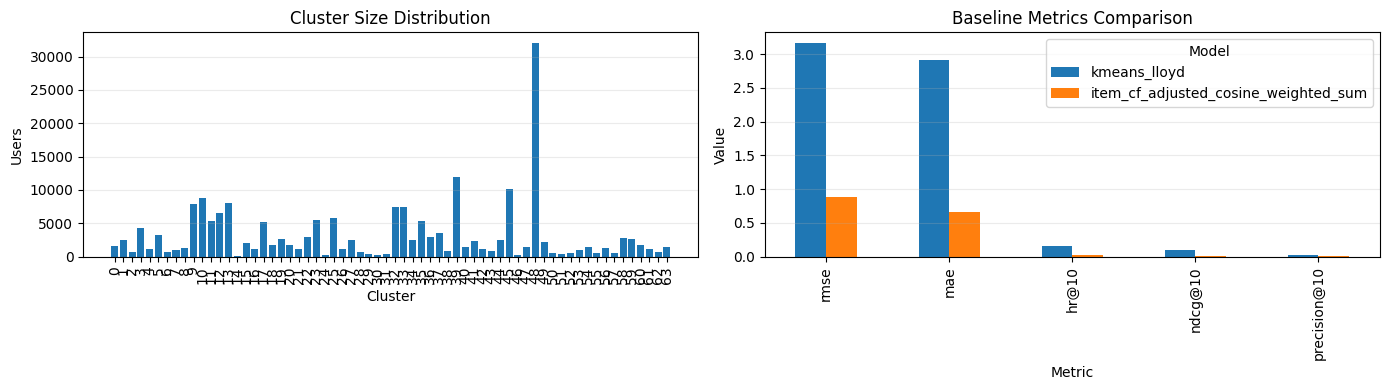

In [17]:
# Visualization 2: Cluster balance + baseline metric comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 4))



# Cluster balance

cluster_counts = pd.Series(classical_clusters).value_counts().sort_index()

axes[0].bar(cluster_counts.index.astype(str), cluster_counts.values)

axes[0].set_title("Cluster Size Distribution")

axes[0].set_xlabel("Cluster")

axes[0].set_ylabel("Users")

axes[0].tick_params(axis="x", labelrotation=90)

axes[0].grid(axis="y", alpha=0.25)



# Baseline metrics

metrics_to_plot = ["rmse", "mae", "hr@10", "ndcg@10", "precision@10"]

plot_df = baseline_metrics.set_index("model")[metrics_to_plot].T

plot_df.plot(kind="bar", ax=axes[1])

axes[1].set_title("Baseline Metrics Comparison")

axes[1].set_xlabel("Metric")

axes[1].set_ylabel("Value")

axes[1].grid(axis="y", alpha=0.25)

axes[1].legend(title="Model")



plt.tight_layout()

plt.show()

In [18]:
# Cell 10: Save required outputs

np.save(OUTPUT_DIR / "classical_clusters.npy", classical_clusters)

baseline_metrics.to_csv(OUTPUT_DIR / "baseline_metrics.csv", index=False)



# Extra tuning artifact for reproducibility

tuning_df.to_csv(OUTPUT_DIR / "classical_tuning_elbow_silhouette_mae.csv", index=False)



print("Saved outputs:")

print(f"- {OUTPUT_DIR / 'classical_clusters.npy'}")

print(f"- {OUTPUT_DIR / 'baseline_metrics.csv'}")

print(f"- {OUTPUT_DIR / 'classical_tuning_elbow_silhouette_mae.csv'}")

Saved outputs:
- data\processed_32m_phase2\classical_clusters.npy
- data\processed_32m_phase2\baseline_metrics.csv
- data\processed_32m_phase2\classical_tuning_elbow_silhouette_mae.csv
